<a href="https://colab.research.google.com/github/seventwentyfor/CSST104-3B-2AY2627/blob/main/LAB_ACT1_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import geopandas as gpd
import folium

Libraries imported successfully ✅


        featurecla  scalerank  LABELRANK                   SOVEREIGNT SOV_A3  \
0  Admin-0 country          1          6                         Fiji    FJI   
1  Admin-0 country          1          3  United Republic of Tanzania    TZA   
2  Admin-0 country          1          7               Western Sahara    SAH   
3  Admin-0 country          1          2                       Canada    CAN   
4  Admin-0 country          1          2     United States of America    US1   

   ADM0_DIF  LEVEL               TYPE TLC                        ADMIN  ...  \
0         0      2  Sovereign country   1                         Fiji  ...   
1         0      2  Sovereign country   1  United Republic of Tanzania  ...   
2         0      2      Indeterminate   1               Western Sahara  ...   
3         0      2  Sovereign country   1                       Canada  ...   
4         1      2            Country   1     United States of America  ...   

      FCLASS_TR     FCLASS_ID     FCLASS_PL 

<Axes: >

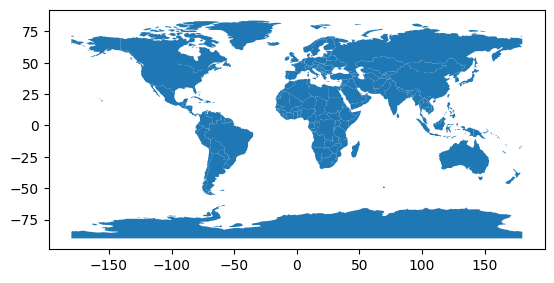

In [ ]:
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

print(world.head())
world.plot()

In [ ]:
print("Current CRS:", world.crs)

Current CRS: EPSG:4326


In [ ]:
world_projected = world.to_crs(epsg=3857)

world_projected["area_m2"] = world_projected.geometry.area

print(world_projected[["ADMIN", "area_m2"]].head())
print("\nArea Reprojection ✓ Complete")

                         ADMIN       area_m2
0                         Fiji  2.128334e+10
1  United Republic of Tanzania  9.522552e+11
2               Western Sahara  1.171023e+11
3                       Canada  5.216648e+13
4     United States of America  2.186228e+13

Area Reprojection ✓ Complete


In [ ]:
world_projected["centroid"] = world_projected.geometry.centroid
world_projected["x"] = world_projected.centroid.x
world_projected["y"] = world_projected.centroid.y

print(world_projected[["ADMIN", "x", "y"]].head())

                         ADMIN             x             y
0                         Fiji  1.824878e+07 -1.958098e+06
1  United Republic of Tanzania  3.869296e+06 -7.003071e+05
2               Western Sahara -1.348403e+06  2.794163e+06
3                       Canada -1.079779e+07  1.044422e+07
4     United States of America -1.329713e+07  6.667416e+06


TASK2:

1.The dataset contains 95 columns, which include various attributes like country names, codes, and population data.

2.The dataset primarily includes MultiPolygon and Polygon geometries, which represent the shapes and boundaries of countries.

3.The geometry column represents the spatial coordinates (longitude and latitude) that define the physical shape and location of each feature on a map.

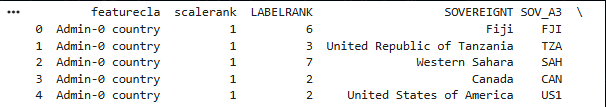

TASK3:

1.EPSG:4326 represents the World Geodetic System 1984 (WGS84), which is the standard coordinate system used by GPS to identify locations on Earth using latitude and longitude.

2.A Coordinate Reference System (CRS) is essential because it tells your software how to project a 3D Earth onto a 2D map, ensuring that distances, areas, and locations are calculated accurately.

TASK4:

1.You can't compute area accurately in EPSG:4326 because it uses degrees as its unit, and degrees don't represent a fixed physical distance; as you move toward the poles, the distance between lines of longitude shrinks, making area calculations inconsistent.

2.EPSG:3857 (Web Mercator) is based on meters, which makes it much more convenient for measuring distances and areas in web maps, though it still suffers from significant scale distortion as you move away from the equator.

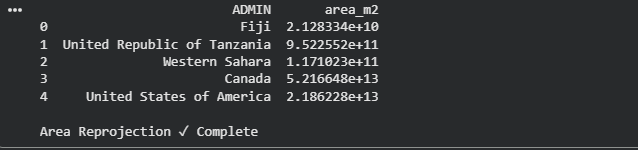

TASK5:

1.A centroid is the geometric center of a shape, representing the average position of all the points that make up that object's boundary.

2.In clustering, centroids serve as the representative location for an entire region, allowing algorithms like K-Means to group neighboring countries or areas based on the physical distance between their center points.

3.We extract X (Longitude) and Y (Latitude) separately because most machine learning models and plotting functions require these as individual numerical features (columns) rather than a combined geometry object.

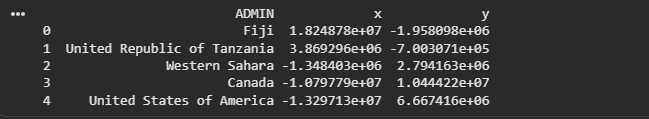

REFLECTION:

One common difficulty is realizing that "coordinates" aren't just numbers; switching between EPSG:4326 (degrees) and EPSG:3857 (meters) can be confusing when your area calculations suddenly result in tiny decimals or massive, distorted numbers. I learned that spatial data is unique because every data point is tied to a physical location on a 3D sphere, meaning the "shape" of the Earth must be mathematically accounted for through a CRS.

Furthermore, extracting centroids taught me that we can simplify complex geographic boundaries into simple X and Y numerical features, making it possible to use standard machine learning tools for spatial clustering